In [6]:
from hubble_utils import load_quasar_data
import pandas as pd
import numpy as np
plt.style.use('style.mplstyle')


#agn_df = load_quasar_data("results/aug10_stonebwb_N30w2000s1000t6c4.h5", populate_sdss=True, apply_cut=False)
agn_df = load_quasar_data("results/data/aug10_stonebwb_nopoly1_recalc_N20w2000s1000t6c4.h5", populate_sdss=True, apply_cut=False)

Reading quasars from HDF5: 100%|██████████| 189/189 [00:00<00:00, 333.55it/s]

Number of quasars loaded: 189
Populating SDSS fields...
Populating SDSS fields: 189



Populating SDSS fields: 100%|██████████| 189/189 [00:12<00:00, 14.86it/s]

Writing 189 quasars to results/data/aug10_stonebwb_nopoly1_recalc_N20w2000s1000t6c4.h5


Length of colin_df: 189
Number with apparent_mag_2500 > 0: 189
Length of merged DataFrame: 189
object_id not in merged: []
Number of quasars with 0 < z <= 1.0: 33
Number of quasars with z > 3: 9
Highest redshift quasar: 4.15
Columns with NaNs: ['chi_sq_g', 'chi_sq_all']
Skipping data cuts as apply_cut is False.


In [24]:
lambda_pivot = {
    'u': 3543,  # SDSS u-band
    'g': 4770,  # SDSS g-band
    'r': 6231,  # SDSS r-band
    'i': 7625,  # SDSS i-band
    'z': 9134,  # SDSS z-band
    'y': 9633,  # PS1 y-band
}

colors = {
    'u': 'tab:blue',
    'g': 'tab:green', 
    'r': 'tab:orange', 
    'i': 'tab:red', 
    'z': 'tab:brown', 
    'y': 'tab:gray'
}


In [25]:
# Calculate and print slopes for sigma and tau panels
def get_slope(x, y, n_bins=12):
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) == 0:
        return np.nan
    xb = np.linspace(x.min(), x.max(), n_bins+1)
    xc = 0.5*(xb[:-1] + xb[1:])
    ymed = []
    for i in range(n_bins):
        m = (x >= xb[i]) & (x < xb[i+1])
        if m.sum() < 5:
            ymed.append(np.nan)
        else:
            ymed.append(np.nanpercentile(y[m], 50))
    xc = xc[np.isfinite(ymed)]
    ymed = np.array(ymed)[np.isfinite(ymed)]
    if len(xc) > 2:
        slope, intercept, *_ = linregress(xc, ymed)
        return slope
    return np.nan

# Gather all points for sigma
x_all_sigma, y_all_sigma = [], []
for b in ('u', 'g', 'r', 'i', 'z'):
    lam_rf = lambda_pivot[b] / (1.0 + agn_df['z'].to_numpy())
    log_lam_rf = np.log10(lam_rf)
    log_sigma  = agn_df[f'log_sigma_band_{b}'].to_numpy()
    mask = np.isfinite(log_lam_rf) & np.isfinite(log_sigma)
    x_all_sigma.append(log_lam_rf[mask])
    y_all_sigma.append(log_sigma[mask])
x_all_sigma = np.concatenate(x_all_sigma)
y_all_sigma = np.concatenate(y_all_sigma)

# Gather all points for tau
x_all_tau, y_all_tau = [], []
for b in ('u', 'g', 'r', 'i', 'z'):
    lam_rf = lambda_pivot[b] / (1.0 + agn_df['z'].to_numpy())
    log_lam_rf = np.log10(lam_rf)
    log_tau    = agn_df[f'log_tau_band_{b}_RF'].to_numpy()
    mask = np.isfinite(log_lam_rf) & np.isfinite(log_tau)
    x_all_tau.append(log_lam_rf[mask])
    y_all_tau.append(log_tau[mask])
x_all_tau = np.concatenate(x_all_tau)
y_all_tau = np.concatenate(y_all_tau)

slope_sigma = get_slope(x_all_sigma, y_all_sigma)
slope_tau = get_slope(x_all_tau, y_all_tau)

print(f"Slope for log_sigma vs log_lambda_RF: {slope_sigma:.4f}")
print(f"Slope for log_tau vs log_lambda_RF:   {slope_tau:.4f}")


Slope for log_sigma vs log_lambda_RF: -0.1991
Slope for log_tau vs log_lambda_RF:   -0.4120


/tmp/ipykernel_1266441/2028770774.py:92: RuntimeWarning: divide by zero encountered in log10
  return np.log10(x)


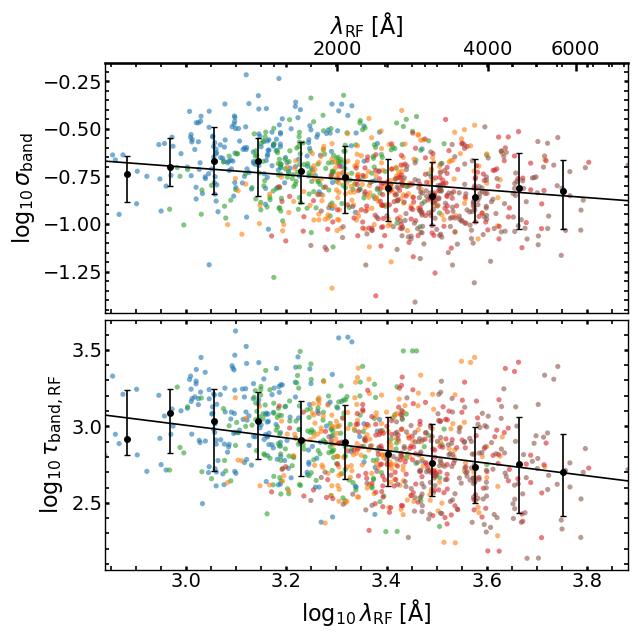

(<Figure size 620x620 with 2 Axes>,
 (<Axes: ylabel='$\\log_{10}\\sigma_{\\mathrm{band}}$'>,
  <Axes: xlabel='$\\log_{10}\\lambda_{\\mathrm{RF}}\\;[\\mathrm{\\AA}]$', ylabel='$\\log_{10}\\tau_{\\mathrm{band,RF}}$'>))

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def plot_sigma_tau_vs_lambda(df, bands=('u', 'g', 'r', 'i', 'z'), n_bins=12, show=True):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.2, 6.2), constrained_layout=True, sharex=True)
    fig.set_constrained_layout_pads(w_pad=0.01, h_pad=0.01, wspace=0.01, hspace=0.02)

    def inward_axes(ax):
        ax.tick_params(direction='in', which='both', top=True, right=True, length=3, pad=2)
        for s in ax.spines.values():
            s.set_linewidth(1.0)

    def bin_stats(x, y, n_bins):
        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]
        if len(x) == 0:
            return np.array([]), np.array([]), np.array([]), np.array([])
        xb = np.linspace(x.min(), x.max(), n_bins+1)
        xc = 0.5*(xb[:-1] + xb[1:])
        ymed, ylo, yhi = [], [], []
        for i in range(n_bins):
            m = (x >= xb[i]) & (x < xb[i+1])
            if m.sum() < 5:
                ymed.append(np.nan); ylo.append(np.nan); yhi.append(np.nan)
            else:
                q16, q50, q84 = np.nanpercentile(y[m], [16, 50, 84])
                ymed.append(q50); ylo.append(q50 - q16); yhi.append(q84 - q50)
        return xc, np.array(ymed), np.array(ylo), np.array(yhi)

    # Collect all points for common x-limits
    x_all_sigma, y_all_sigma = [], []
    x_all_tau,   y_all_tau   = [], []

    # Top panel scatter
    for b in bands:
        lam_rf = lambda_pivot[b] / (1.0 + df['z'].to_numpy())
        log_lam_rf = np.log10(lam_rf)
        log_sigma  = df[f'log_sigma_band_{b}'].to_numpy()
        mask = np.isfinite(log_lam_rf) & np.isfinite(log_sigma)
        ax1.scatter(log_lam_rf[mask], log_sigma[mask], s=14, alpha=0.6,
                    color=colors[b], edgecolor='none', zorder=1)
        x_all_sigma.append(log_lam_rf[mask])
        y_all_sigma.append(log_sigma[mask])

    # Bottom panel scatter
    for b in bands:
        lam_rf = lambda_pivot[b] / (1.0 + df['z'].to_numpy())
        log_lam_rf = np.log10(lam_rf)
        log_tau    = df[f'log_tau_band_{b}_RF'].to_numpy()
        mask = np.isfinite(log_lam_rf) & np.isfinite(log_tau)
        ax2.scatter(log_lam_rf[mask], log_tau[mask], s=14, alpha=0.6,
                    color=colors[b], edgecolor='none', zorder=1)
        x_all_tau.append(log_lam_rf[mask])
        y_all_tau.append(log_tau[mask])

    # Binned medians for sigma
    x_all_sigma = np.concatenate(x_all_sigma)
    y_all_sigma = np.concatenate(y_all_sigma)
    xc, ymed, ylo, yhi = bin_stats(x_all_sigma, y_all_sigma, n_bins)
    ok = np.isfinite(ymed)
    ax1.errorbar(xc[ok], ymed[ok], yerr=[ylo[ok], yhi[ok]], fmt='o', color='k',
                 ms=4, lw=1.2, capsize=2.5, zorder=3)
    if ok.sum() > 2:
        slope, intercept, *_ = linregress(xc[ok], ymed[ok])
        xfit = np.linspace(np.nanmin(x_all_sigma), np.nanmax(x_all_sigma), 200)
        ax1.plot(xfit, slope*xfit + intercept, color='k', lw=1.2, zorder=2)

    # Binned medians for tau
    x_all_tau = np.concatenate(x_all_tau)
    y_all_tau = np.concatenate(y_all_tau)
    xc, ymed, ylo, yhi = bin_stats(x_all_tau, y_all_tau, n_bins)
    ok = np.isfinite(ymed)
    ax2.errorbar(xc[ok], ymed[ok], yerr=[ylo[ok], yhi[ok]], fmt='o', color='k',
                 ms=4, lw=1.2, capsize=2.5, zorder=3)
    if ok.sum() > 2:
        slope, intercept, *_ = linregress(xc[ok], ymed[ok])
        xfit = np.linspace(np.nanmin(x_all_tau), np.nanmax(x_all_tau), 200)
        ax2.plot(xfit, slope*xfit + intercept, color='k', lw=1.2, zorder=2)

    # Labels and style
    ax1.set_ylabel(r'$\log_{10}\sigma_{\mathrm{band}}$')
    ax2.set_ylabel(r'$\log_{10}\tau_{\mathrm{band,RF}}$')
    ax2.set_xlabel(r'$\log_{10}\lambda_{\mathrm{RF}}\;[\mathrm{\AA}]$')
    inward_axes(ax1)
    inward_axes(ax2)

    # Top axis in wavelength (Å) with dynamically chosen nice ticks
    def loglam_to_angstrom(x):
        return 10**x
    def angstrom_to_loglam(x):
        return np.log10(x)

    secax = ax1.secondary_xaxis('top', functions=(loglam_to_angstrom, angstrom_to_loglam))
    secax.set_xlabel(r'$\lambda_{\mathrm{RF}}\;[\mathrm{\AA}]$')
    secax.tick_params(direction='in', which='both', top=True)

    # Determine tick step dynamically
    lam_min = 10**np.nanmin(x_all_sigma)
    lam_max = 10**np.nanmax(x_all_sigma)
    lam_range = lam_max - lam_min

    # choose step from [100, 200, 500, 1000] Å
    possible_steps = np.array([100, 200, 500, 1000, 2000])
    step = possible_steps[np.argmin(np.abs(lam_range / possible_steps - 4))]  # aim for ~4 ticks
    tick_vals = np.arange(np.floor(lam_min / step) * step,
                          np.ceil(lam_max / step) * step + step, step)
    secax.set_xticks(tick_vals)

    ax2.set_xlim(np.nanmin(x_all_sigma), np.nanmax(x_all_sigma))

    

    if show:
        plt.show()
    return fig, (ax1, ax2)


plot_sigma_tau_vs_lambda(agn_df)

/tmp/ipykernel_1266441/1348681187.py:108: RuntimeWarning: divide by zero encountered in log10
  def A_to_loglam(x): return np.log10(x)


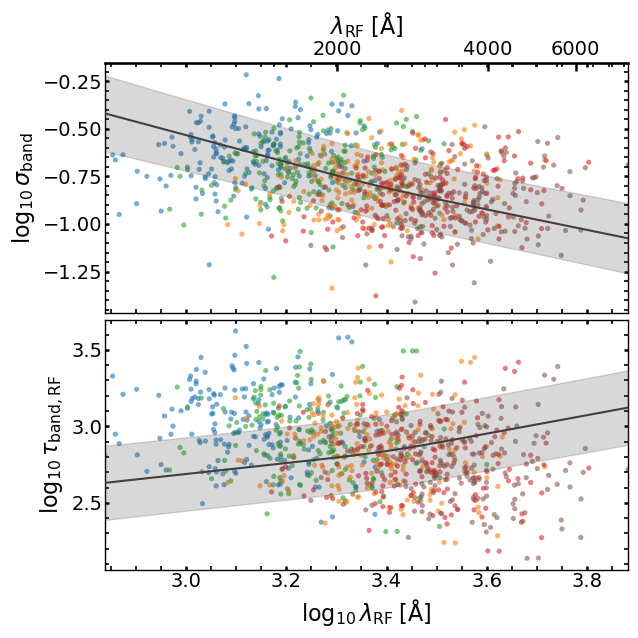

(<Figure size 620x620 with 2 Axes>,
 (<Axes: ylabel='$\\log_{10}\\sigma_{\\mathrm{band}}$'>,
  <Axes: xlabel='$\\log_{10}\\lambda_{\\mathrm{RF}}\\;[\\mathrm{\\AA}]$', ylabel='$\\log_{10}\\tau_{\\mathrm{band,RF}}$'>))

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def log_broken_pl_np(lam, lam_s, d1, d2, ds=0.1):
    x = lam / lam_s
    delta = d2 - d1
    smooth_exp = 1.0 / ds
    log10_1px = np.log1p(x**smooth_exp) / np.log(10.0)
    log_f = d1 * np.log10(x) + (delta / smooth_exp) * log10_1px
    return log_f - (delta / smooth_exp) * np.log10(2.0)  # normalized at lam_s

def plot_sigma_tau_vs_lambda_with_model(df, bands=('u', 'g', 'r', 'i', 'z'),
                                        n_bins=12, show=True):
    """
    Two stacked panels:
      Top:    log10(sigma_band) vs log10(lambda_RF)
      Bottom: log10(tau_band_RF) vs log10(lambda_RF)

    Model ribbons (mean ± 1σ) computed exactly like your processing:
      log_sigma_band   = log_sigma0 + log_broken_pl(...)
      log_tau_band_RF  = log_tau_drw0 - log10(1+z) + log_broken_pl(...),
      with tau slopes (eta_tau1, eta_tau2) ALWAYS used for tau.

    Requires in df (per row): lam_s, eta_A1, eta_A2, eta_tau1, eta_tau2, eta_break,
                              log_sigma0, log_tau_drw0, z, and per-band summaries
                              log_sigma_band_{b}, log_tau_band_{b}_RF.
    Assumes lambda_pivot, colors, and log_broken_pl_np() are defined.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.2, 6.2),
                                   constrained_layout=True, sharex=True)
    fig.set_constrained_layout_pads(w_pad=0.01, h_pad=0.01, wspace=0.01, hspace=0.02)

    def inward(ax):
        ax.tick_params(direction='in', which='both', top=True, right=True, length=3, pad=2)
        for s in ax.spines.values():
            s.set_linewidth(1.0)

    # --- scatter (points a bit larger, less transparent)
    x_all = []
    for b in bands:
        lam_rf = lambda_pivot[b] / (1.0 + df['z'].to_numpy())
        x = np.log10(lam_rf)
        y_sigma = df[f'log_sigma_band_{b}'].to_numpy()
        y_tau   = df[f'log_tau_band_{b}_RF'].to_numpy()

        m1 = np.isfinite(x) & np.isfinite(y_sigma)
        m2 = np.isfinite(x) & np.isfinite(y_tau)

        ax1.scatter(x[m1], y_sigma[m1], s=14, alpha=0.6, color=colors[b], edgecolor='none', zorder=1)
        ax2.scatter(x[m2], y_tau[m2],   s=14, alpha=0.6, color=colors[b], edgecolor='none', zorder=1)

        x_all.append(x[m1])

    x_all = np.concatenate(x_all) if len(x_all) else np.array([])
    if x_all.size:
        xmin, xmax = np.nanmin(x_all), np.nanmax(x_all)
        ax2.set_xlim(xmin, xmax)
    else:
        xmin, xmax = 3.3, 3.9  # fallback

    # --- model ribbons (use data-driven wavelength range)
    lam_min, lam_max = 10**xmin, 10**xmax
    lam_grid = np.linspace(lam_min, lam_max, 400)    # Å
    loglam_grid = np.log10(lam_grid)

    model_sigma_all, model_tau_all = [], []
    for _, row in df.iterrows():
        lam_s = row['lam_s']

        # Shapes
        shp_sigma = log_broken_pl_np(lam_grid, lam_s,
                                     row['eta_A1'],  row['eta_A2'],  row['eta_break'])
        shp_tau   = log_broken_pl_np(lam_grid, lam_s,
                                     row['eta_tau1'], row['eta_tau2'], row['eta_break'])

        # Intercepts (already base-10)
        sig0_10 = row['log_sigma0']
        tau0_10 = row['log_tau_drw0'] - np.log10(1.0 + row['z'])

        model_sigma_all.append(sig0_10 + shp_sigma)
        model_tau_all.append(tau0_10 + shp_tau)

    model_sigma_all = np.asarray(model_sigma_all)
    model_tau_all   = np.asarray(model_tau_all)

    if model_sigma_all.size:
        mu, sd = np.nanmean(model_sigma_all, axis=0), np.nanstd(model_sigma_all, axis=0)
        ax1.plot(loglam_grid, mu, color='0.25', lw=1.5, zorder=5)
        ax1.fill_between(loglam_grid, mu - sd, mu + sd, color='0.25', alpha=0.2, zorder=4)

    if model_tau_all.size:
        mu, sd = np.nanmean(model_tau_all, axis=0), np.nanstd(model_tau_all, axis=0)
        ax2.plot(loglam_grid, mu, color='0.25', lw=1.5, zorder=5)
        ax2.fill_between(loglam_grid, mu - sd, mu + sd, color='0.25', alpha=0.2, zorder=4)

    # --- labels & axes
    ax1.set_ylabel(r'$\log_{10}\sigma_{\mathrm{band}}$')
    ax2.set_ylabel(r'$\log_{10}\tau_{\mathrm{band,RF}}$')
    ax2.set_xlabel(r'$\log_{10}\lambda_{\mathrm{RF}}\;[\mathrm{\AA}]$')
    inward(ax1); inward(ax2)

    # Top axis in Å with dynamic, rounded ticks
    def loglam_to_A(x): return 10**x
    def A_to_loglam(x): return np.log10(x)
    secax = ax1.secondary_xaxis('top', functions=(loglam_to_A, A_to_loglam))
    secax.set_xlabel(r'$\lambda_{\mathrm{RF}}\;[\mathrm{\AA}]$')
    secax.tick_params(direction='in', which='both', top=True)

    rng = lam_max - lam_min
    steps = np.array([100, 200, 500, 1000, 2000])
    step = steps[np.argmin(np.abs(rng/steps - 5))]  # aim for ~5 ticks
    ticks = np.arange(np.floor(lam_min/step)*step, np.ceil(lam_max/step)*step + step, step)
    secax.set_xticks(ticks)

    plt.savefig('plots/appendix/sigma_tau_vs_lambda.png', dpi=600)

    if show:
        plt.show()
    return fig, (ax1, ax2)




plot_sigma_tau_vs_lambda_with_model(agn_df)